# Data with Pandas

Since Pandas is a third-party Python library (not part of the standard Python libraries), we need to **import** it.


### <font color='red'>***You must run this next cell in order for any of the pandas steps to work!***</font>

In [1]:
import pandas as pd

### The data we're using today

For this lesson, we will be using the Portal Teaching data (https://figshare.com/articles/Portal_Project_Teaching_Database/1314459), a subset of the data from Ernst et al Long-term monitoring and experimental manipulation of a Chihuahuan Desert ecosystem near Portal, Arizona, USA (https://doi.org/10.1890/15-2115.1)

This section will use a data file called **surveys.csv** which we will download from the Internet shortly.

(If needed, it can also be downloaded from here:  https://ndownloader.figshare.com/files/2292172)

Each row in the data file records the species and weight of each animal caught in plots in the study area.

The columns represent:

| Column 	| Description |
| --- | --- |
| record_id |	Unique id for the observation|
| month |	month of observation |
|day 	|day of observation|
|year |	year of observation|
|plot_id 	|ID of a particular plot|
|species_id |	2-letter code|
|sex |	sex of animal ("M", "F")|
|hindfoot_length |	length of the hindfoot in mm|
|weight |	weight of the animal in grams|

Each time we call a function that's in a library, we use the syntax *`LibraryName.FunctionName`*. Adding the library name with a `.` before the function name tells Python where to find the function. In the example above, we have imported Pandas as `pd`. This means we don't have to type out `pandas` each time we call a Pandas function.

## Loading data

Let's use Pandas' built-in function, `read_csv`, that reads in a CSV file:

In [2]:
# To download the file from the internet:
# pd.read_csv("https://raw.githubusercontent.com/gwu-libraries/gwlibraries-workshops/master/python-programming/surveys.csv")

pd.read_csv('https://go.gwu.edu/pywdata1')
# Or if you're able to download the file locally:
# pd.read_csv("surveys.csv")

# If you're inside Google Colaboratory, you can borrow code from
# https://colab.research.google.com/notebooks/io.ipynb?authuser=1 to load files from your computer
# (Just paste in the code under "Uploading files from your local file system")

,record_id,month,day,year,plot_id,species_id,sex,hindfoot_length,weight
0,1,7,16,1977,2,NL,M,32.0,NaN
1,2,7,16,1977,3,NL,M,33.0,NaN
2,3,7,16,1977,2,DM,F,37.0,NaN
3,4,7,16,1977,7,DM,M,36.0,NaN
4,5,7,16,1977,3,DM,M,35.0,NaN
...,...,...,...,...,...,...,...,...,...
35544,35545,12,31,2002,15,AH,NaN,NaN,NaN
35545,35546,12,31,2002,15,AH,NaN,NaN,NaN
35546,35547,12,31,2002,10,RM,F,15.0,14.0
35547,35548,12,31,2002,7,DO,M,36.0,51.0


That read our CSV file, but we'd like to store it as an **object**.  So we'll create a variable for it, called `surveys_df`.  This is just like how we used a variable above to store an integer, or a string, or a list, or a dictionary.  We're just storing a Pandas DataFrame object instead.

Make sure to run the cell below:

In [3]:
# To download the file from the internet:
surveys_df = pd.read_csv("https://go.gwu.edu/pywdata1")

# Or if you're able to download the file locally:
#surveys_df = pd.read_csv("surveys.csv")

Try evaluating `surveys_df`:

In [4]:
surveys_df

,record_id,month,day,year,plot_id,species_id,sex,hindfoot_length,weight
0,1,7,16,1977,2,NL,M,32.0,NaN
1,2,7,16,1977,3,NL,M,33.0,NaN
2,3,7,16,1977,2,DM,F,37.0,NaN
3,4,7,16,1977,7,DM,M,36.0,NaN
4,5,7,16,1977,3,DM,M,35.0,NaN
...,...,...,...,...,...,...,...,...,...
35544,35545,12,31,2002,15,AH,NaN,NaN,NaN
35545,35546,12,31,2002,15,AH,NaN,NaN,NaN
35546,35547,12,31,2002,10,RM,F,15.0,14.0
35547,35548,12,31,2002,7,DO,M,36.0,51.0


## Properties of a Pandas `DataFrame`

How would you now check what **class** (type) of object `surveys_df` is?

In [5]:
type(surveys_df)

pandas.core.frame.DataFrame

`surveys_df` is a Pandas **DataFrame**.   A DataFrame is a 2-dimensional structure that can store data in rows and columns - similar to a spreadsheet or a table, but with some other nice features.  (Yes, it's very similar to a `data.frame` in R.)

Just like the Pandas *library* has functions, *objects* can have **functions** (which may take arguments) and **attributes** (which don't).

A Pandas DataFrame object has an attribute called `dtypes` which lists out the type of each column. Try it:

In [6]:
surveys_df.dtypes

,0
record_id,int64
month,int64
day,int64
year,int64
plot_id,int64
species_id,object
sex,object
hindfoot_length,float64
weight,float64


Try these to see what they do:

    surveys_df.columns
    surveys_df.head()
Also, what does `surveys_df.head(15)` do, versus `surveys_df.head(4)`?

    surveys_df.tail()
    surveys_df.shape


Take note of the output of the shape method. What format does it return the shape of the DataFrame in?

In [7]:
type(surveys_df.shape)

tuple

## Slicing and Dicing (Subsetting)

What if we want to isolate just one column?  There are (at least) two ways we can do this:

- We can use bracket notation, like this:

    `mydataframe['myvariable']`

- We can treat the variable like an attribute, like this:

    `mydataframe.myvariable`


Try it for `surveys_df` and the `species_id` variable:

In [8]:
surveys_df.species_id

,species_id
0,NL
1,NL
2,DM
3,DM
4,DM
...,...
35544,AH
35545,AH
35546,RM
35547,DO


or

In [9]:
surveys_df['species_id']

,species_id
0,NL
1,NL
2,DM
3,DM
4,DM
...,...
35544,AH
35545,AH
35546,RM
35547,DO


Let's see what type `surveys_df['species_id']` is, using the `type()` function that we used this morning.  Try it.

In [10]:
type(surveys_df['species_id'])

pandas.core.series.Series

You can think of a Pandas **Series** as a series of observations of one variable.  It behaves like a Python list.

We can also slice and dice -- similar to how we selected parts of list objects above.  Try getting back the 3rd through 10th rows of `surveys_df` using this structure:

`df[2:5]` # returns rows 2 through 4 of `df`

In [11]:
surveys_df[3:10]

,record_id,month,day,year,plot_id,species_id,sex,hindfoot_length,weight
3,4,7,16,1977,7,DM,M,36.0,NaN
4,5,7,16,1977,3,DM,M,35.0,NaN
5,6,7,16,1977,1,PF,M,14.0,NaN
6,7,7,16,1977,2,PE,F,NaN,NaN
7,8,7,16,1977,1,DM,M,37.0,NaN
8,9,7,16,1977,1,DM,F,34.0,NaN
9,10,7,16,1977,6,PF,F,20.0,NaN


Or, we can select just certain columns with a structure like this:

df[['variableA', 'variableB']] # returns a DataFrame with `variableA` and `variableB` from `df`

Use this structure to get back a `DataFrame` containg just the `species_id` and `hindfood_length` columns from `surveys_df`:

In [12]:
surveys_df[['species_id', 'hindfoot_length']]

,species_id,hindfoot_length
0,NL,32.0
1,NL,33.0
2,DM,37.0
3,DM,36.0
4,DM,35.0
...,...,...
35544,AH,NaN
35545,AH,NaN
35546,RM,15.0
35547,DO,36.0


What if we want to get a subset on both columns _and_ rows?

Another way to select is with `.loc`, which selects based on *labels* (as opposed to `.iloc` which selects using *numerical indices*).  Try this:

In [13]:
surveys_df.loc[[3, 10, 12], ['day', 'year', 'species_id']]

,day,year,species_id
3,16,1977,DM
10,16,1977,DS
12,16,1977,DM


We can also use `.query` to select only rows matching certain conditions.  Note that the query expression is in single quotes.

In [14]:
surveys_df.query('hindfoot_length < 10')

,record_id,month,day,year,plot_id,species_id,sex,hindfoot_length,weight
407,408,11,14,1977,8,PF,F,9.0,6.0
5800,5801,4,29,1982,7,RM,NaN,8.0,16.0
10066,10067,3,16,1985,19,RM,M,6.0,16.0
19014,19015,9,9,1991,19,BA,F,7.0,11.0
19190,19191,10,11,1991,13,PF,F,8.0,15.0
19566,19567,1,8,1992,19,BA,M,6.0,8.0
20561,20562,12,22,1992,5,RM,F,9.0,17.0
21035,21036,8,19,1993,21,PF,F,7.0,6.0
31399,31400,9,30,2000,19,PB,M,2.0,30.0
31456,31457,9,31,2000,6,RM,M,8.0,8.0


There are other ways to do this.  Try this expression:

In [15]:
surveys_df['hindfoot_length'] < 10

,hindfoot_length
0,False
1,False
2,False
3,False
4,False
...,...
35544,False
35545,False
35546,False
35547,False


How can I tally up the number of False and True values in the series above?

In [16]:
(surveys_df['hindfoot_length'] < 10).value_counts()

,count
hindfoot_length,
False,35538
True,11


How can you use this to get back a data frame with only the rows in `surveys_df` where `hindfoot_length < 10`?

In [17]:
surveys_df[surveys_df['hindfoot_length'] < 10]

,record_id,month,day,year,plot_id,species_id,sex,hindfoot_length,weight
407,408,11,14,1977,8,PF,F,9.0,6.0
5800,5801,4,29,1982,7,RM,NaN,8.0,16.0
10066,10067,3,16,1985,19,RM,M,6.0,16.0
19014,19015,9,9,1991,19,BA,F,7.0,11.0
19190,19191,10,11,1991,13,PF,F,8.0,15.0
19566,19567,1,8,1992,19,BA,M,6.0,8.0
20561,20562,12,22,1992,5,RM,F,9.0,17.0
21035,21036,8,19,1993,21,PF,F,7.0,6.0
31399,31400,9,30,2000,19,PB,M,2.0,30.0
31456,31457,9,31,2000,6,RM,M,8.0,8.0


**Challenge**:  How might you query to get back only rows with `hindfoot_length < 10` **and** `weight > 10` in ONE expression?  (There is more than one way to accomplish this!)

Another handy operator is `~` (tilde), which gives us the "opposite" of a result.  Let's say we want to get all of the `AB` species observations, but only where the `hindfoot_length` variable has a value:

In [18]:
surveys_df.loc[(surveys_df.species_id == 'DM') & ~surveys_df.hindfoot_length.isnull()]

,record_id,month,day,year,plot_id,species_id,sex,hindfoot_length,weight
2,3,7,16,1977,2,DM,F,37.0,NaN
3,4,7,16,1977,7,DM,M,36.0,NaN
4,5,7,16,1977,3,DM,M,35.0,NaN
7,8,7,16,1977,1,DM,M,37.0,NaN
8,9,7,16,1977,1,DM,F,34.0,NaN
...,...,...,...,...,...,...,...,...,...
35532,35533,12,31,2002,14,DM,F,36.0,48.0
35533,35534,12,31,2002,14,DM,M,37.0,56.0
35534,35535,12,31,2002,14,DM,M,37.0,53.0
35535,35536,12,31,2002,14,DM,F,35.0,42.0


## Basic descriptive statistics

### Numerical data

We see from above that we can also isolate just the data in one column. Let's try isolating the weight column, and calling the describe() function to get some statistics on it.

In [19]:
surveys_df.weight.describe()

,weight
count,32283.000000
mean,42.672428
std,36.631259
min,4.000000
25%,20.000000
50%,37.000000
75%,48.000000
max,280.000000


We can also ask for descriptive statistics for one of the numerical variables:

In [20]:
surveys_df['weight'].mean()

np.float64(42.672428212991356)

Using corr(), we can also get a pairwise correlation between every pair of numerical variables.  We need to set `numeric_only=True` since we have a few non-numeric variables, which we want to exclude (otherwise we'll get an error).

In [21]:
surveys_df.corr(numeric_only=True)

,record_id,month,day,year,plot_id,hindfoot_length,weight
record_id,1.000000,0.073746,0.017181,0.997570,-0.004048,-0.285324,-0.273123
month,0.073746,1.000000,0.011461,0.031071,0.020908,-0.013346,-0.002618
day,0.017181,0.011461,1.000000,0.018490,0.020142,-0.006067,-0.013013
year,0.997570,0.031071,0.018490,1.000000,-0.004230,-0.287259,-0.276595
plot_id,-0.004048,0.020908,0.020142,-0.004230,1.000000,-0.126284,-0.061435
hindfoot_length,-0.285324,-0.013346,-0.006067,-0.287259,-0.126284,1.000000,0.683813
weight,-0.273123,-0.002618,-0.013013,-0.276595,-0.061435,0.683813,1.000000


### Categorical Data

We can use `.describe()` on a `Series` containing text to get some basic descriptive information.

In [22]:
species_data = surveys_df.species_id
species_data.describe()

,species_id
count,34786
unique,48
top,DM
freq,10596


For categorical data, we can also find out how many there are of each unique value, using `.value_counts()`

In [23]:
species_data.value_counts()

,count
species_id,
DM,10596
PP,3123
DO,3027
PB,2891
RM,2609
DS,2504
OT,2249
PF,1597
PE,1299


Pandas has a handy `unique()` function (well, it has many handy functions!) to get all the unique elements in a `Series`:

In [24]:
unique_species = pd.unique(surveys_df['species_id'])
unique_species

array(['NL', 'DM', 'PF', 'PE', 'DS', 'PP', 'SH', 'OT', 'DO', 'OX', 'SS',
       'OL', 'RM', nan, 'SA', 'PM', 'AH', 'DX', 'AB', 'CB', 'CM', 'CQ',
       'RF', 'PC', 'PG', 'PH', 'PU', 'CV', 'UR', 'UP', 'ZL', 'UL', 'CS',
       'SC', 'BA', 'SF', 'RO', 'AS', 'SO', 'PI', 'ST', 'CU', 'SU', 'RX',
       'PB', 'PL', 'PX', 'CT', 'US'], dtype=object)

Try evaluting the **`.size`** attribute on the above result to see how many unique species there are in the data set.

In [25]:
unique_species.size

49

## Grouping

Pandas can also sort and group data based on the values in a column:

In [26]:
grouped_by_species = surveys_df.groupby('species_id')

`.groupby` doesn't appear to do anything until we perform subsequent steps.

In [27]:
grouped_by_species.head()

,record_id,month,day,year,plot_id,species_id,sex,hindfoot_length,weight
0,1,7,16,1977,2,NL,M,32.0,NaN
1,2,7,16,1977,3,NL,M,33.0,NaN
2,3,7,16,1977,2,DM,F,37.0,NaN
3,4,7,16,1977,7,DM,M,36.0,NaN
4,5,7,16,1977,3,DM,M,35.0,NaN
...,...,...,...,...,...,...,...,...,...
34516,34517,7,13,2002,23,RO,M,17.0,11.0
35511,35512,12,31,2002,11,US,NaN,NaN,NaN
35512,35513,12,31,2002,11,US,NaN,NaN,NaN
35527,35528,12,31,2002,13,US,NaN,NaN,NaN


But now try running **`describe()`** on `grouped_by_species`:

In [28]:
# grouped_by_species.describe() # gives maybe MORE info than we care about
grouped_by_species.describe()

record_id                                                          \
               count          mean           std      min       25%      50%   
species_id                                                                     
AB             303.0  13201.702970   5835.874869   3126.0   7604.00  13829.0   
AH             437.0  21631.716247   7194.381201   1446.0  15507.00  21600.0   
AS               2.0  19760.000000   1170.968830  18932.0  19346.00  19760.0   
BA              46.0  18586.043478    921.349203  16598.0  17972.50  18803.0   
CB              50.0  18300.460000   7271.702586   3189.0  13227.00  19590.5   
CM              13.0   4055.000000   2789.266660   3190.0   3263.00   3291.0   
CQ              16.0   5718.062500   1899.301607   3200.0   3720.75   6199.0   
CS               1.0  15878.000000           NaN  15878.0  15878.00  15878.0   
CT               1.0  28988.000000           NaN  28988.0  28988.00  28988.0   
CU               1.0  21209.000000           NaN  21209.0  21209.00  21209.0   
CV               1.0  13313.000000           NaN  13313.0  13313.00  13313.0   
DM           10596.0  15776.228011   9758.042325      3.0   7466.75  15092.5   
DO            3027.0  17970.353485   9529.235809     68.0  10263.50  17078.0   
DS            2504.0   6096.122204   5002.986094     11.0   2309.25   4727.5   
DX              40.0  22236.350000   6588.027227   2706.0  19710.50  20573.5   
NL            1252.0  13902.781949   9459.788377      1.0   6433.00  12609.0   
OL            1006.0  11097.006958   6911.769060    274.0   5414.50  10230.5   
OT            2249.0  19908.781236  10566.087720     36.0  10438.00  21535.0   
OX              12.0   4548.666667   7204.725739     70.0    174.25    287.5   
PB            2891.0  31423.223452   2822.580268  22711.0  29478.00  31659.0   
PC              39.0  17035.974359   4799.825751   6567.0  14617.00  18500.0   
PE            1299.0  15920.995381   8076.090716      7.0  11336.50  15107.0   
PF            1597.0  17347.086412   9151.113902      6.0   7210.00  21566.0   
PG               8.0  16909.000000   6389.064385   7352.0  14992.75  17017.0   
PH              32.0  16061.343750   4843.685258   9476.0  10943.00  17213.5   
PI               9.0  31139.444444   5558.186915  20408.0  32708.00  33769.0   
PL              36.0  26021.750000   1856.592507  22817.0  24864.75  26629.0   
PM             899.0  19354.033370   8470.264362    883.0  12496.50  23878.0   
PP            3123.0  25281.530900   7599.657786     18.0  21748.50  26181.0   
PU               5.0  16813.000000   6548.811304   9643.0   9650.00  21342.0   
PX               6.0  26337.333333   2903.952663  23435.0  24749.50  25064.0   
RF              75.0  15888.293333   2076.856856   5764.0  15480.00  15929.0   
RM            2609.0  16410.623994   6241.789011    311.0  13027.00  16752.0   
RO               8.0  32526.875000   5589.994823  18871.0  33516.25  34041.0   
RX               2.0  23703.500000   2006.061938  22285.0  22994.25  23703.5   
SA              75.0   9089.466667   5389.253424    779.0   5743.00   8314.0   
SC               1.0  16002.000000           NaN  16002.0  16002.00  16002.0   
SF              43.0  20809.116279   6630.187048  16659.0  16994.00  17514.0   
SH             147.0  19330.231293   7796.076966     24.0  15046.50  16088.0   
SO              43.0  20457.627907   1616.424096  19125.0  19552.50  19972.0   
SS             248.0  16291.798387   9037.762489     77.0   9436.75  14832.0   
ST               1.0  20723.000000           NaN  20723.0  20723.00  20723.0   
SU               5.0  22160.400000    197.865611  21807.0  22233.00  22247.0   
UL               4.0  19403.250000   3381.668954  14466.0  18580.50  20773.0   
UP               8.0  14816.750000   1327.000565  13688.0  14013.25  14226.5   
UR              10.0  21367.000000   8568.125738  13564.0  13719.75  19103.5   
US               4.0  35524.250000     15.063753  35512.0  35512.75  35520.5   
ZL         

Try grouping by multiple variables.  You will need to pass a **list** of variables to group on.

In [29]:
surveys_df.groupby(['species_id', 'sex']).describe()

record_id                                                 \
                   count          mean           std      min       25%   
species_id sex                                                            
AH         M         1.0  22330.000000           NaN  22330.0  22330.00   
BA         F        31.0  18658.451613    739.410208  16951.0  18192.00   
           M        14.0  18385.857143   1263.788009  16598.0  17224.00   
DM         F      4554.0  15448.699605   9838.059000      3.0   7300.00   
           M      5969.0  16071.827944   9683.266977      4.0   7698.00   
DO         F      1308.0  17035.387615   9498.939008     68.0   9489.75   
           M      1707.0  18670.820738   9508.424375    378.0  10850.00   
DS         F      1188.0   6015.080808   5344.848913     11.0   1737.75   
           M      1270.0   6151.857480   4646.277986     58.0   2931.75   
NL         F       675.0  14693.844444   9458.327256     22.0   7957.00   
           M       502.0  13648.402390   8894.100213      1.0   6246.00   
OL         F       475.0  10934.692632   6632.174760    274.0   4889.50   
           M       512.0  11484.576172   7034.072650    666.0   6535.50   
OT         F      1057.0  20190.142857  10522.302762     36.0  10861.00   
           M      1156.0  20035.259516  10324.348123    248.0  10913.00   
OX         F         4.0    137.250000     54.137941     70.0    105.25   
           M         5.0   6492.200000   6734.289176    166.0    242.00   
PB         F      1646.0  31631.981166   2781.279402  22711.0  29712.50   
           M      1216.0  31143.734375   2852.579657  23239.0  28837.75   
PE         F       579.0  16256.756477   8002.343103      7.0  12558.00   
           M       698.0  15652.796562   8107.066794     60.0  10887.00   
PF         F       757.0  18019.494055   9007.282228     10.0   7800.00   
           M       816.0  16950.351716   9168.175024      6.0   7092.50   
PH         F        21.0  16552.571429   4293.914305   9576.0  16629.00   
           M        11.0  15123.545455   5863.483374   9476.0  10881.00   
PI         M         8.0  32480.875000   4098.573739  22507.0  32855.00   
PL         F        16.0  25629.000000   1674.986249  23135.0  24271.50   
           M        19.0  26521.157895   1842.128095  23147.0  25096.50   
PM         F       382.0  20084.845550   8304.379945    883.0  12742.00   
           M       501.0  18880.964072   8508.817697   1140.0  12429.00   
PP         F      1608.0  24701.294776   7986.681193     49.0  21067.25   
           M      1468.0  25984.515668   7117.074348     18.0  22507.75   
PX         F         1.0  24991.000000           NaN  24991.0  24991.00   
           M         1.0  25137.000000           NaN  25137.0  25137.00   
RF         F        57.0  16234.736842   1498.061432  14062.0  15516.00   
           M        18.0  14791.222222   3115.490020   5764.0  15285.75   
RM         F      1199.0  16235.573812   6044.637645    397.0  12925.50   
           M      1349.0  16628.435137   6419.443775    311.0  13315.00   
RO         F         4.0  30831.250000   8022.649869  18871.0  29891.50   
           M         4.0  34222.500000    939.221131  33397.0  33516.25   
RX         M         2.0  23703.500000   2006.061938  22285.0  22994.25   
SF         F        17.0  19949.117647   5965.160831  16669.0  16897.00   
           M        23.0  20942.913043   6879.122552  16659.0  17060.50   
SH         F        78.0  17526.833333   5526.805750   6080.0  15043.25   
           M        65.0  21446.738462   9137.795136     24.0  15387.00   
SO         F        32.0  20524.531250   1826.305772  19125.0  19469.25   
           M        11.0  20263.000000    760.370831  19280.0  19741.00   
SS         F         1.0   4875.000000           NaN   4875.0   4875.00   
           M         2.0  10465.000000  13382.702941   1002.0   5733.50   

                                             month             ...  \
                    50%       75%      max  

Now we're going to create some series with:

* The number of animals observed per species
* The mean weight of all animals observed in each species

In [30]:
# a series with the mean weight by species
species_mean_weights = grouped_by_species['weight'].mean()
species_mean_weights

,weight
species_id,
AB,NaN
AH,NaN
AS,NaN
BA,8.600000
CB,NaN
CM,NaN
CQ,NaN
CS,NaN
CT,NaN


If we want, we can drop missing values:

In [31]:
grouped_by_species['weight'].mean().dropna()

,weight
species_id,
BA,8.600000
DM,43.157864
DO,48.870523
DS,120.130546
NL,159.245660
OL,31.575258
OT,24.230556
OX,21.000000
PB,31.735943


We can sort to find the species with the highest mean weights.  Remember that `species_mean_weights` is a Series, so we can use its `.sort_values()` method.  Additionally, we can use the optional `ascending` parameter to control whether it sorts in ascending or descending order.

In [32]:
species_mean_weights.sort_values(ascending = False)

,weight
species_id,
NL,159.245660
DS,120.130546
SS,93.500000
SH,73.148936
SF,58.878049
SO,55.414634
DO,48.870523
DM,43.157864
PB,31.735943


We can also get the tally of species observations by using `Series.value_counts()`.  Notice that by default, `Series.value_counts` sorts in descending order.

In [33]:
species_counts = surveys_df.species_id.value_counts()
species_counts

,count
species_id,
DM,10596
PP,3123
DO,3027
PB,2891
RM,2609
DS,2504
OT,2249
PF,1597
PE,1299


(For future reference:  `.agg()` or `.aggregate()` can be a useful way to work with "groupby" objects)

## Merging (Joining) data frames

Let's read in a second data frame from `https://go.gwu.edu/pywdata2`, and call it `species_df`

In [34]:
species_df = pd.read_csv('https://go.gwu.edu/pywdata2')
species_df

,species_id,genus,species,taxa
0,AB,Amphispiza,bilineata,Bird
1,AH,Ammospermophilus,harrisi,Rodent
2,AS,Ammodramus,savannarum,Bird
3,BA,Baiomys,taylori,Rodent
4,CB,Campylorhynchus,brunneicapillus,Bird
5,CM,Calamospiza,melanocorys,Bird
6,CQ,Callipepla,squamata,Bird
7,CS,Crotalus,scutalatus,Reptile
8,CT,Cnemidophorus,tigris,Reptile
9,CU,Cnemidophorus,uniparens,Reptile


We can "calculate" a new text variable (let's call it `genus_species`) by concatenating the values of `genus` and `species`:

In [35]:
species_df['genus_species'] = species_df['genus'] + ' ' + species_df['species']
species_df

,species_id,genus,species,taxa,genus_species
0,AB,Amphispiza,bilineata,Bird,Amphispiza bilineata
1,AH,Ammospermophilus,harrisi,Rodent,Ammospermophilus harrisi
2,AS,Ammodramus,savannarum,Bird,Ammodramus savannarum
3,BA,Baiomys,taylori,Rodent,Baiomys taylori
4,CB,Campylorhynchus,brunneicapillus,Bird,Campylorhynchus brunneicapillus
5,CM,Calamospiza,melanocorys,Bird,Calamospiza melanocorys
6,CQ,Callipepla,squamata,Bird,Callipepla squamata
7,CS,Crotalus,scutalatus,Reptile,Crotalus scutalatus
8,CT,Cnemidophorus,tigris,Reptile,Cnemidophorus tigris
9,CU,Cnemidophorus,uniparens,Reptile,Cnemidophorus uniparens


Let's now "join" the common name onto the existing, surveys_df data frame.

A brief summary of ways we can join table A and table B:
- **left join** keeps all rows in table A, adds on columns from table B but only for rows where the "key" matches.  Where there's no matching row in table B, the result is "NA" (missing data) in the variables from table B.
- **right join** keeps all rows in table B, adds on columns from table A but only for rows where the "key" matches.  Where there's no matching row in table A, the result is "NA" (missing data) in the variables from table A.
- **inner join** keeps ONLY the rows where there is a match between table A and table B (based on the "key" variable in common)
- **outer join** keeps ALL rows in BOTH table A and table B.  For rows the key's value is only found in table A, the variables from table B will have missing data; for rows the key's value is only found in table B, the variables from table A will have missing data.

In our case, we will do a left join, because we want to keep all the original data in `surveys_df`, but we wish to enhance it with the name for the species, where it is available in `species_df`.

We will use the `.merge()` method available on the `surveys_df` DataFrame.  We need to give it a few things:
* The second data frame that we wish to merge onto this one.
* The variable(s) that we want to merge on.  In other words, the variable(s) that will need to match between the two data frames.  This parameter is called `on`.
* The method of merging (see above).  This parameter is called `how`.

In [36]:
surveys_df = surveys_df.merge(species_df[['species_id', 'genus_species', 'taxa']],
                              on='species_id', how='left')
surveys_df

,record_id,month,day,year,plot_id,species_id,sex,hindfoot_length,weight,genus_species,taxa
0,1,7,16,1977,2,NL,M,32.0,NaN,Neotoma albigula,Rodent
1,2,7,16,1977,3,NL,M,33.0,NaN,Neotoma albigula,Rodent
2,3,7,16,1977,2,DM,F,37.0,NaN,Dipodomys merriami,Rodent
3,4,7,16,1977,7,DM,M,36.0,NaN,Dipodomys merriami,Rodent
4,5,7,16,1977,3,DM,M,35.0,NaN,Dipodomys merriami,Rodent
...,...,...,...,...,...,...,...,...,...,...,...
35544,35545,12,31,2002,15,AH,NaN,NaN,NaN,Ammospermophilus harrisi,Rodent
35545,35546,12,31,2002,15,AH,NaN,NaN,NaN,Ammospermophilus harrisi,Rodent
35546,35547,12,31,2002,10,RM,F,15.0,14.0,Reithrodontomys megalotis,Rodent
35547,35548,12,31,2002,7,DO,M,36.0,51.0,Dipodomys ordii,Rodent


## Plotting with Matplotlib

Let's try creating some quick bar charts.  First we need to make sure figures appear inline in the notebook:

In [37]:
import matplotlib.pyplot as plt

%matplotlib inline

And now we'll create some quick charts using `plt.scatter()` followed by `plt.show()`:

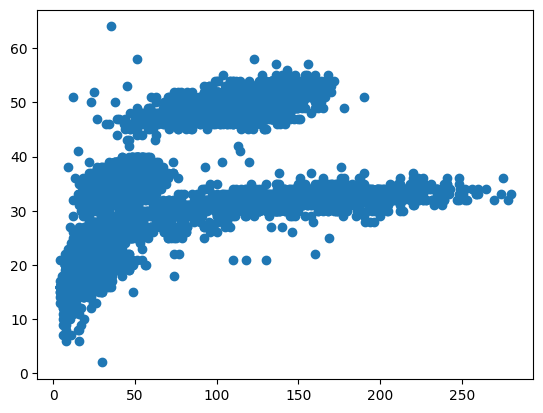

In [38]:
plt.scatter(x = surveys_df.weight, y=surveys_df.hindfoot_length)

plt.show()

We can also use `plt.hist()` to create a histogram.  Create a histogram of the values of `surveys_df.hindfoot_length`.

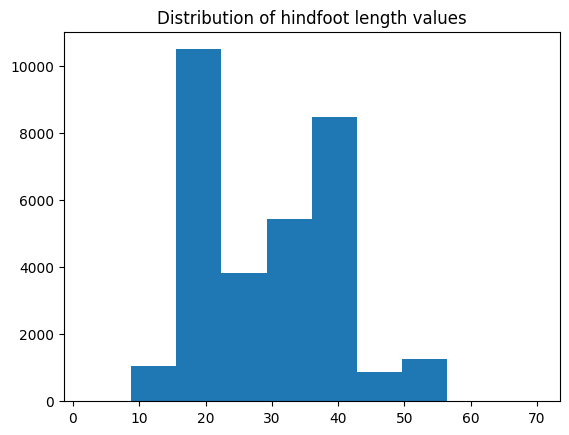

In [39]:
plt.hist(surveys_df.hindfoot_length)
plt.title('Distribution of hindfoot length values')
plt.show()

We can also call `.plot()` on a Series.  We can specify which type of plot we want by populating the `kind` parameter.  For a bar plot, we can specify `kind = 'bar'`.

<Axes: xlabel='species_id'>

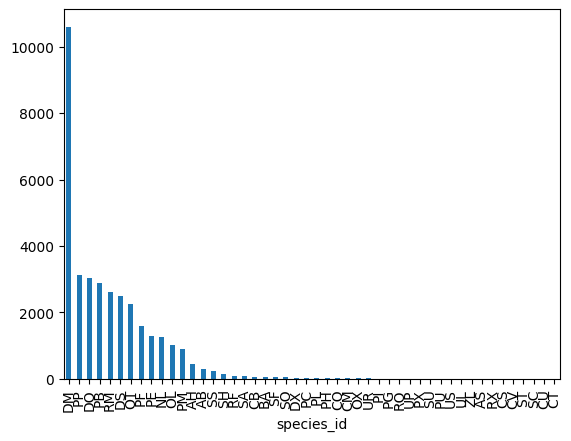

In [40]:
species_counts.plot(kind='bar')

And we can control the size of the figure by adding a `figsize` parameter to `plot()`.  For example, we can add `figsize=(15,5)` where 15 is the width and 5 is the height.

<Axes: xlabel='species_id'>

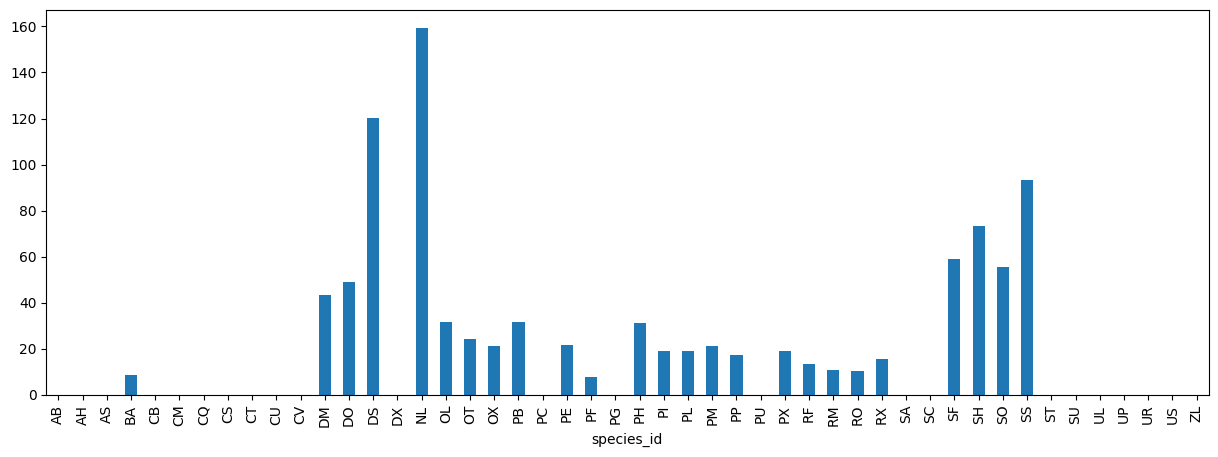

In [41]:
species_mean_weights.plot(kind='bar', figsize=(15,5))

And now for a scatter plot (`kind = 'scatter'`), where we specify the names of the `x` and `y` variables:

<Axes: xlabel='weight', ylabel='hindfoot_length'>

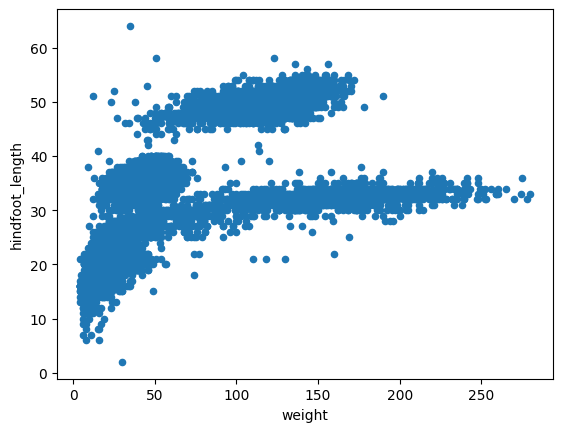

In [42]:
surveys_df.plot(kind='scatter', y='hindfoot_length', x='weight')

But let's look up what more we can do with this plot.  Try looking up help on `matplotlib.pyplot.scatter`

In [43]:
help(plt.scatter)

Help on function scatter in module matplotlib.pyplot:

scatter(x: 'float | ArrayLike', y: 'float | ArrayLike', s: 'float | ArrayLike | None' = None, c: 'ArrayLike | Sequence[ColorType] | ColorType | None' = None, *, marker: 'MarkerType | None' = None, cmap: 'str | Colormap | None' = None, norm: 'str | Normalize | None' = None, vmin: 'float | None' = None, vmax: 'float | None' = None, alpha: 'float | None' = None, linewidths: 'float | Sequence[float] | None' = None, edgecolors: "Literal['face', 'none'] | ColorType | Sequence[ColorType] | None" = None, colorizer: 'Colorizer | None' = None, plotnonfinite: 'bool' = False, data=None, **kwargs) -> 'PathCollection'
    A scatter plot of *y* vs. *x* with varying marker size and/or color.

    Parameters
    ----------
    x, y : float or array-like, shape (n, )
        The data positions.

    s : float or array-like, shape (n, ), optional
        The marker size in points**2 (typographic points are 1/72 in.).
        Default is ``rcParams['li

Let's try using a few of these parameters, like `marker`, `alpha` and `c` (color)

<Axes: xlabel='weight', ylabel='hindfoot_length'>

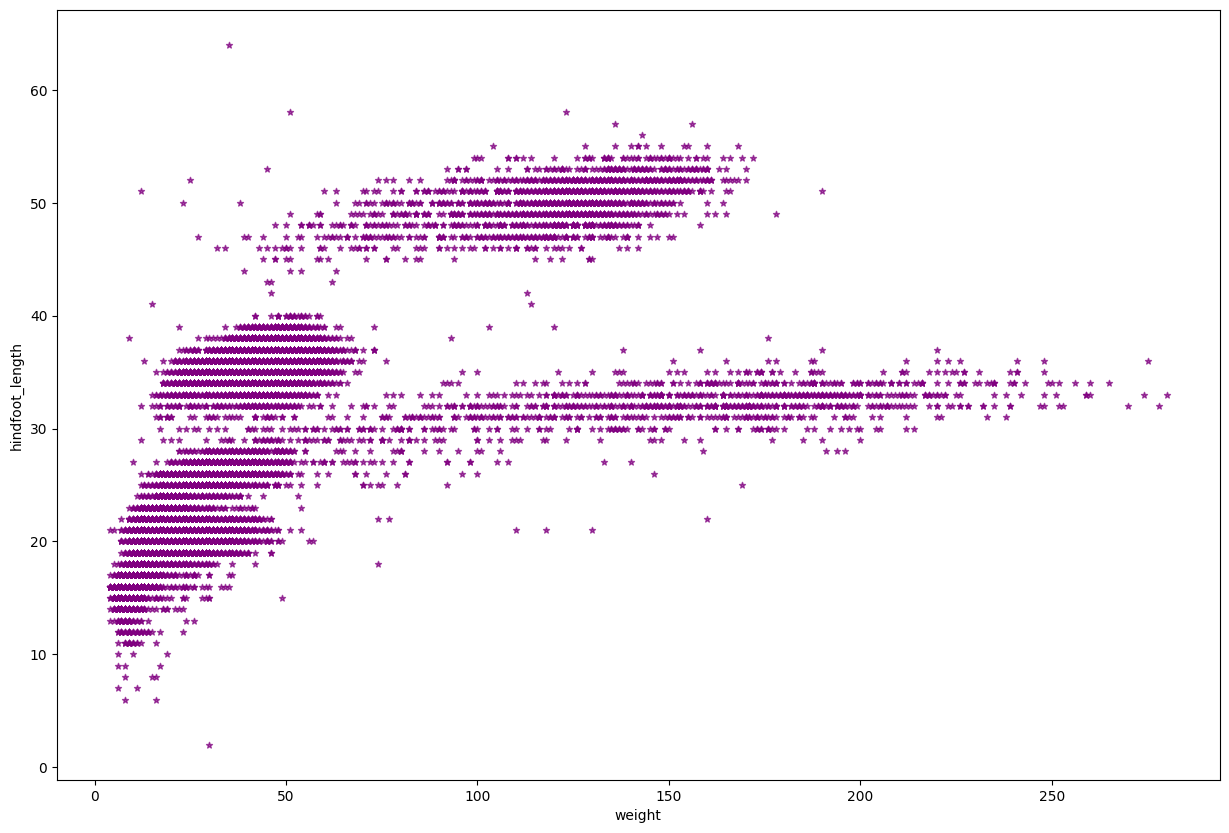

In [44]:
surveys_df.plot(kind='scatter', y='hindfoot_length', x='weight', figsize=(15, 10), marker="*", alpha=0.7, c='purple')

See if you can look up another plot type and get it to work!

## Nicer plotting, with `ggplot`

Let's try a different plotting library, called `ggplot` (from the `plotnine` package), that thinks about plotting data in a different way, in terms of "adding" *data* plus *aesthetics* (colors, shapes, etc.) plus *layers* (which add to or modify the plot)

In Python, the `ggplot` library is available as part of the `plotline` package.

In [45]:
from plotnine import *

The first thing we'll do is create a ggplot object using `ggplot()` and give it:
- Our data frame (`surveys_df`)
- Aesthetics information, such as which variables in our data frame will be used as the independent (x) and dependent (y) variables.  We'll add (using `+`) `aes(x, y)`

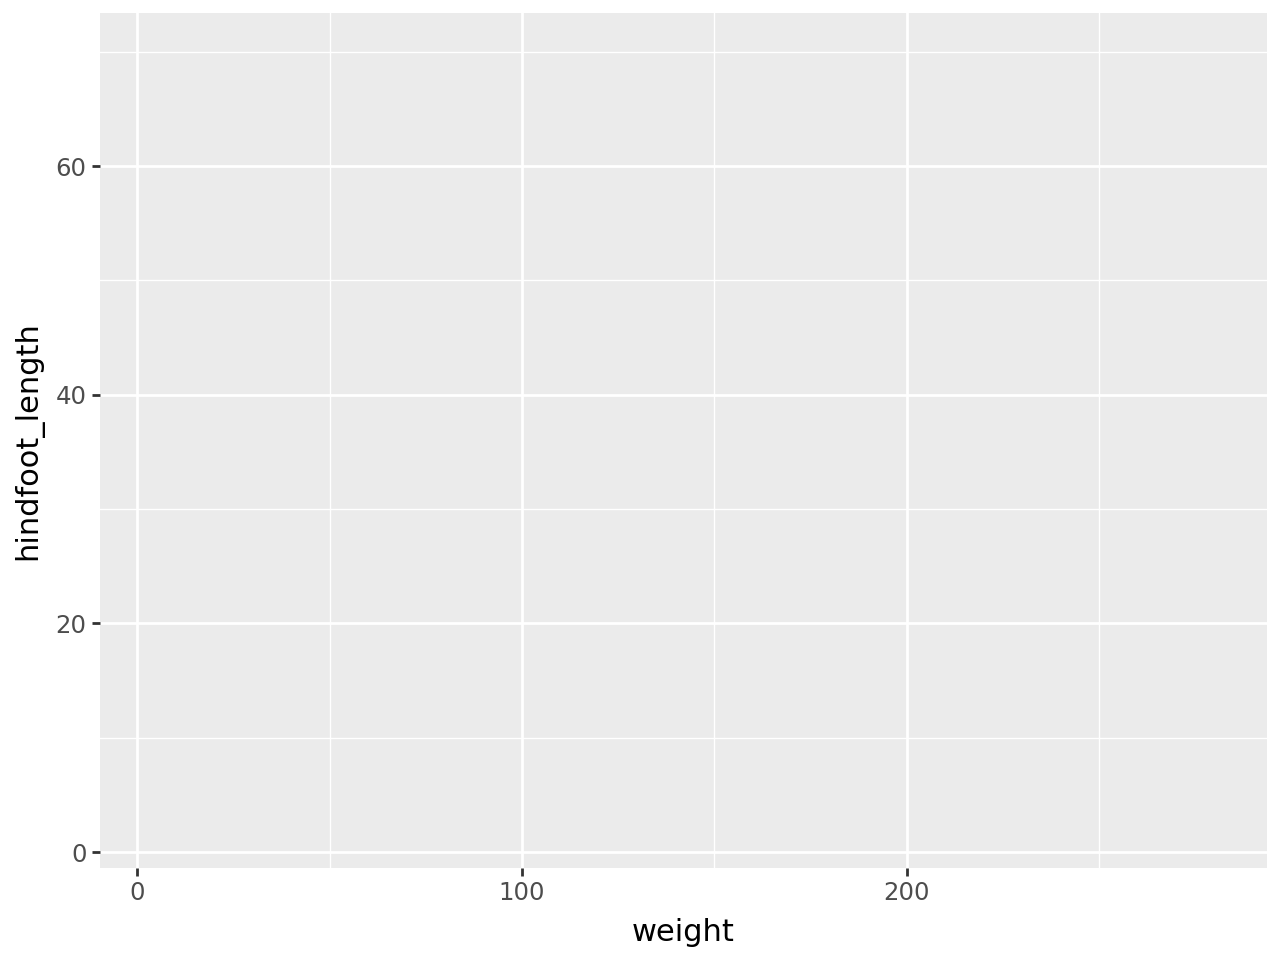

In [46]:
ggplot(surveys_df) + aes(x = 'weight', y = 'hindfoot_length')

Hmmm, we get a canvas but it's mysteriously empty!   We need to add a ***layer***, using `+`.  We'll add a layer with points, using `geom_point()`.

/usr/local/lib/python3.12/dist-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 4811 rows containing missing values.


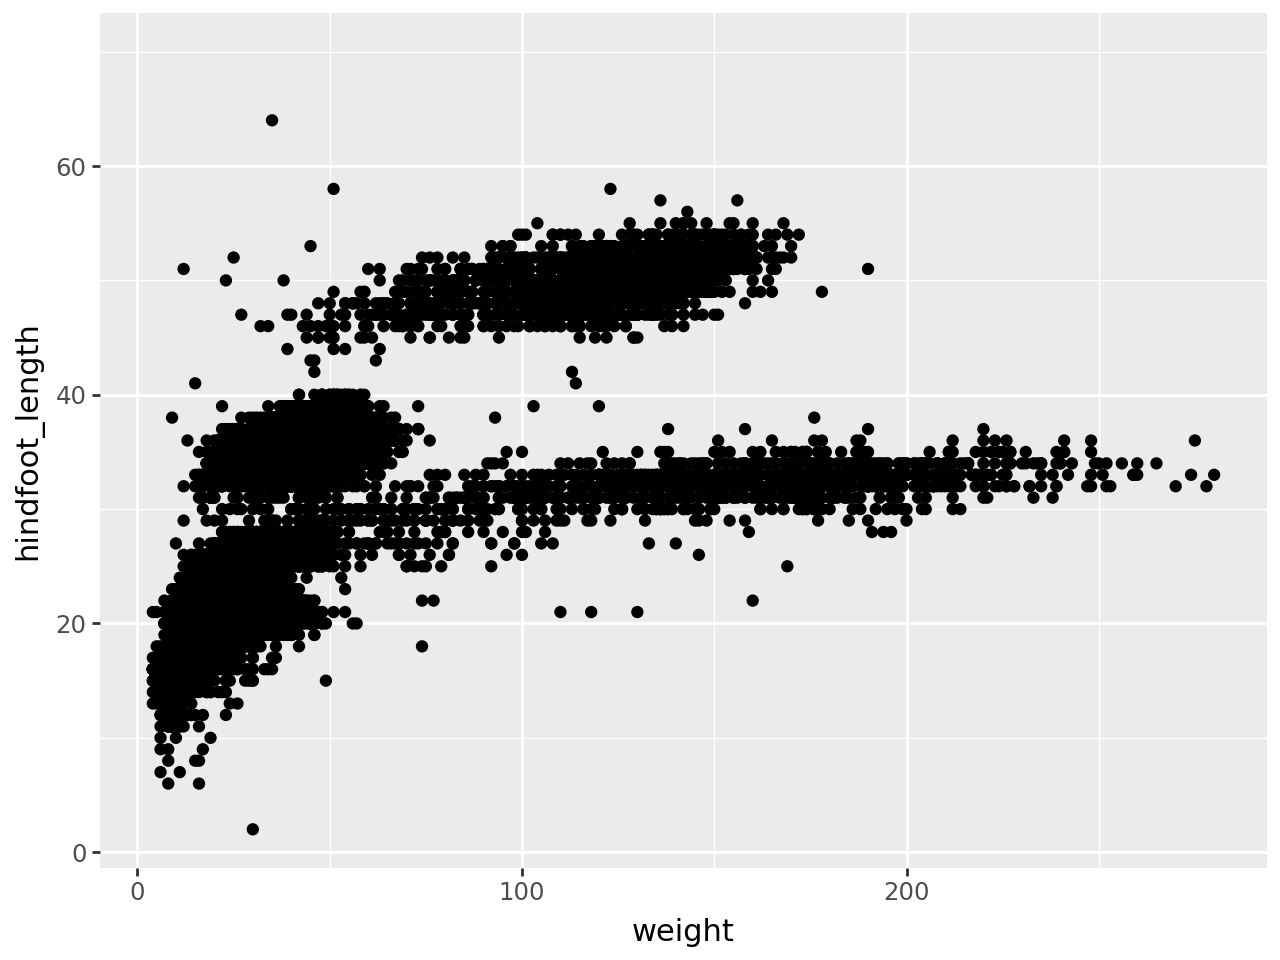

In [47]:
ggplot(surveys_df) + aes(x = 'weight', y = 'hindfoot_length') + geom_point()

Not bad!  Let's see if we can perhaps color-code the points based on the species_id, by adding a `color` parameter to the `aes()` component.

/usr/local/lib/python3.12/dist-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 4811 rows containing missing values.


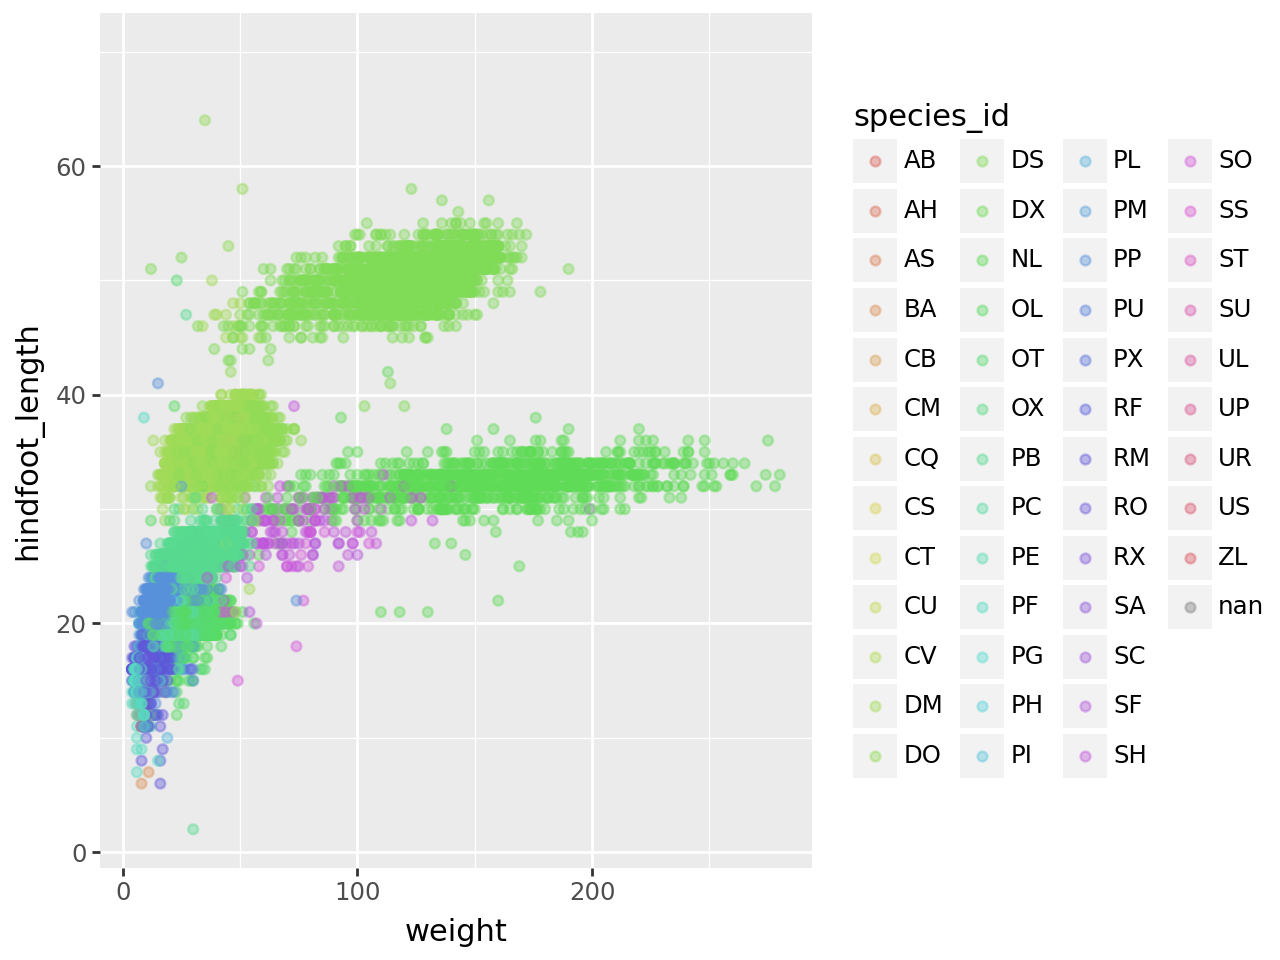

In [48]:
ggplot(surveys_df) + aes(x = 'weight', y = 'hindfoot_length',
                         color='species_id') + \
geom_point(alpha = 0.4)

This is great, but, perhaps with so many species_id values, it becomes hard to distinguish between the colors to have a meaningful color layer.   Let's create a subset using just the top 10 species.

Remember earlier we created `species_counts`?  We'll use it here, to get just the top ten species as as a list:

In [49]:
species_counts

,count
species_id,
DM,10596
PP,3123
DO,3027
PB,2891
RM,2609
DS,2504
OT,2249
PF,1597
PE,1299


How would you get just the first 10 values?

In [50]:
species_counts[0:10]

,count
species_id,
DM,10596
PP,3123
DO,3027
PB,2891
RM,2609
DS,2504
OT,2249
PF,1597
PE,1299


But we simply want the species ids, not any of the other stuff.  Similar to a Python dictionary, we can use `.keys()` to get that:

In [51]:
species_counts[:10].keys()

Index(['DM', 'PP', 'DO', 'PB', 'RM', 'DS', 'OT', 'PF', 'PE', 'NL'], dtype='object', name='species_id')

And let's use a variable to store our index of top species so we can reuse it:

In [52]:
top_species = species_counts[:10].keys()

Now that we have a simple list of the top 10 species IDs, we can use `.isin()` to create a subset data frame containing just the rows with those species_id values.  Let's call this new data frame `subset_df`:

In [53]:
subset_df = surveys_df[surveys_df.species_id.isin(top_species)]
subset_df

,record_id,month,day,year,plot_id,species_id,sex,hindfoot_length,weight,genus_species,taxa
0,1,7,16,1977,2,NL,M,32.0,NaN,Neotoma albigula,Rodent
1,2,7,16,1977,3,NL,M,33.0,NaN,Neotoma albigula,Rodent
2,3,7,16,1977,2,DM,F,37.0,NaN,Dipodomys merriami,Rodent
3,4,7,16,1977,7,DM,M,36.0,NaN,Dipodomys merriami,Rodent
4,5,7,16,1977,3,DM,M,35.0,NaN,Dipodomys merriami,Rodent
...,...,...,...,...,...,...,...,...,...,...,...
35540,35541,12,31,2002,15,PB,F,24.0,31.0,Chaetodipus baileyi,Rodent
35541,35542,12,31,2002,15,PB,F,26.0,29.0,Chaetodipus baileyi,Rodent
35542,35543,12,31,2002,15,PB,F,27.0,34.0,Chaetodipus baileyi,Rodent
35546,35547,12,31,2002,10,RM,F,15.0,14.0,Reithrodontomys megalotis,Rodent


Now that our new data frame has a smaller variety of species, let's try it again with `genus_species` as the key for the color:

In [54]:
surveys_plot = ggplot(subset_df) + \
  aes(x = 'weight', y = 'hindfoot_length', color='genus_species') + \
  geom_point(alpha=0.2)

And now to render the plot:

/usr/local/lib/python3.12/dist-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 2572 rows containing missing values.


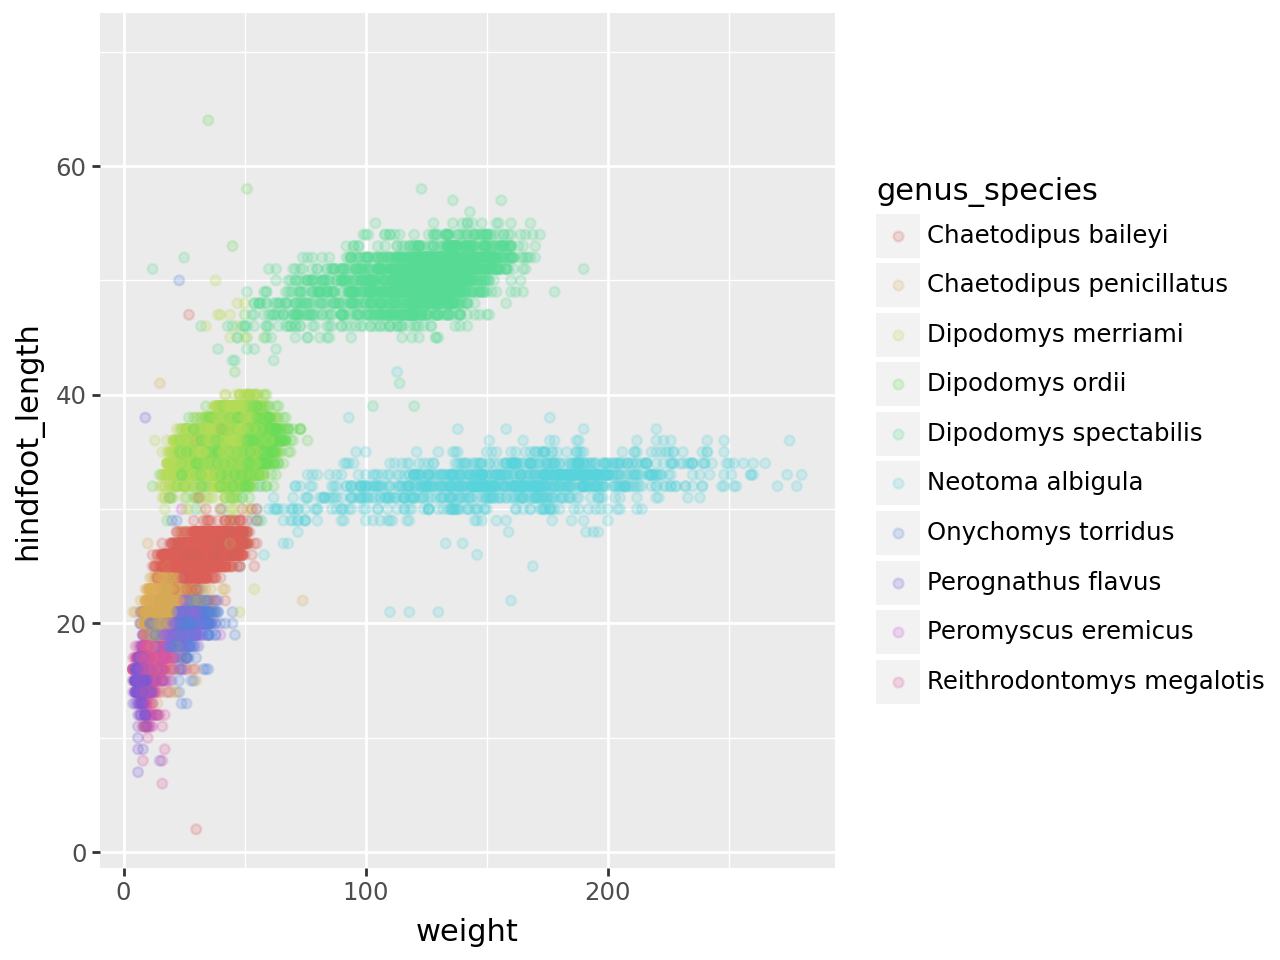

In [55]:
surveys_plot

Here are some other layers we can try adding.  See what the `stat_smooth()` and `theme_xkcd()` layers do:

/usr/local/lib/python3.12/dist-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 2572 rows containing missing values.


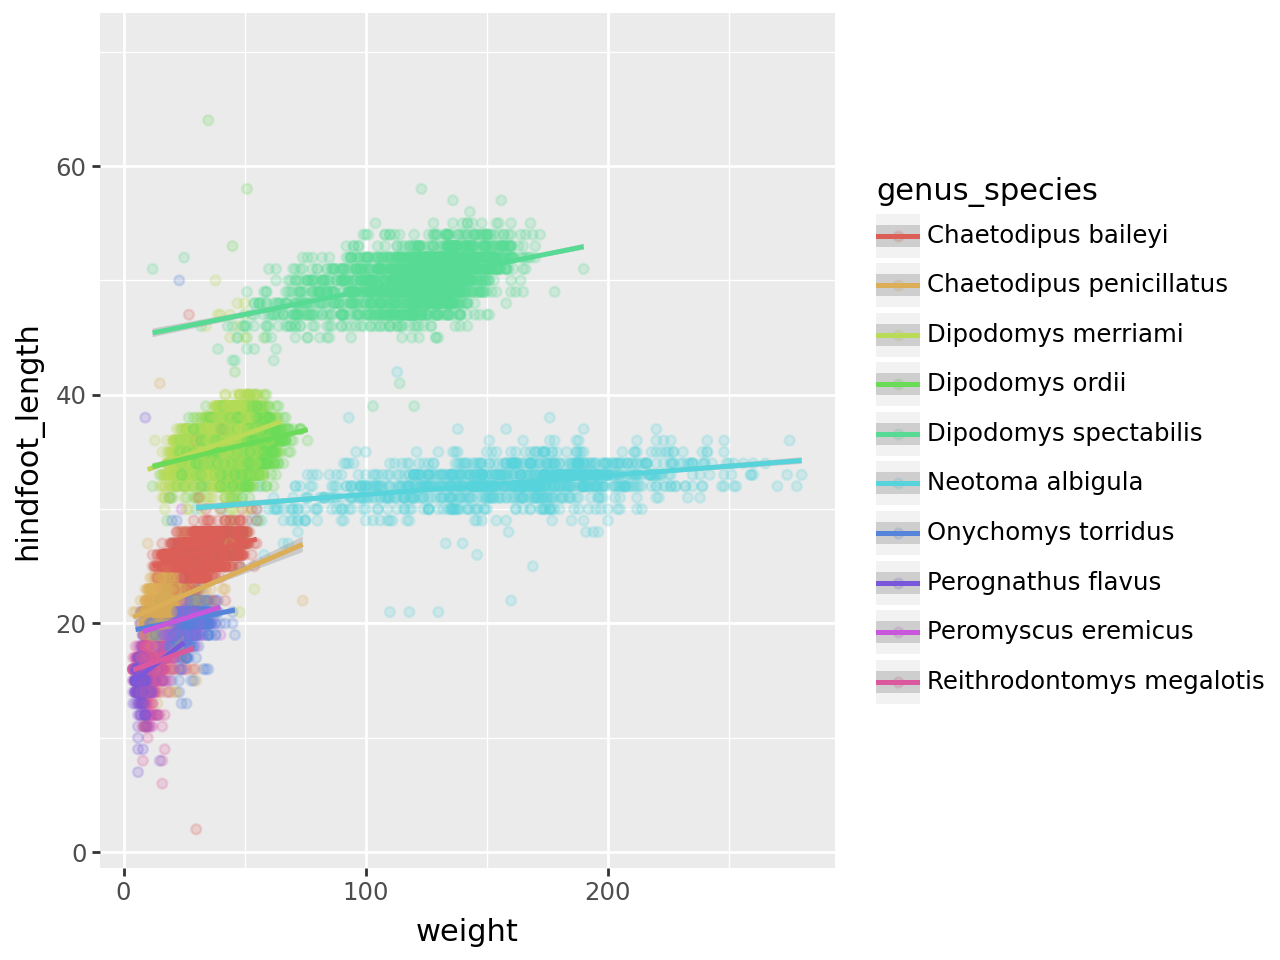

In [56]:
surveys_plot + stat_smooth()

We can also try `facet_wrap('~variablename')` and pass it the name of the variable we'd like to use as our facet.  Let's facet on `species_id` so we can look at the hindfoot_length vs. weight for each species separately:

/usr/local/lib/python3.12/dist-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 2572 rows containing missing values.


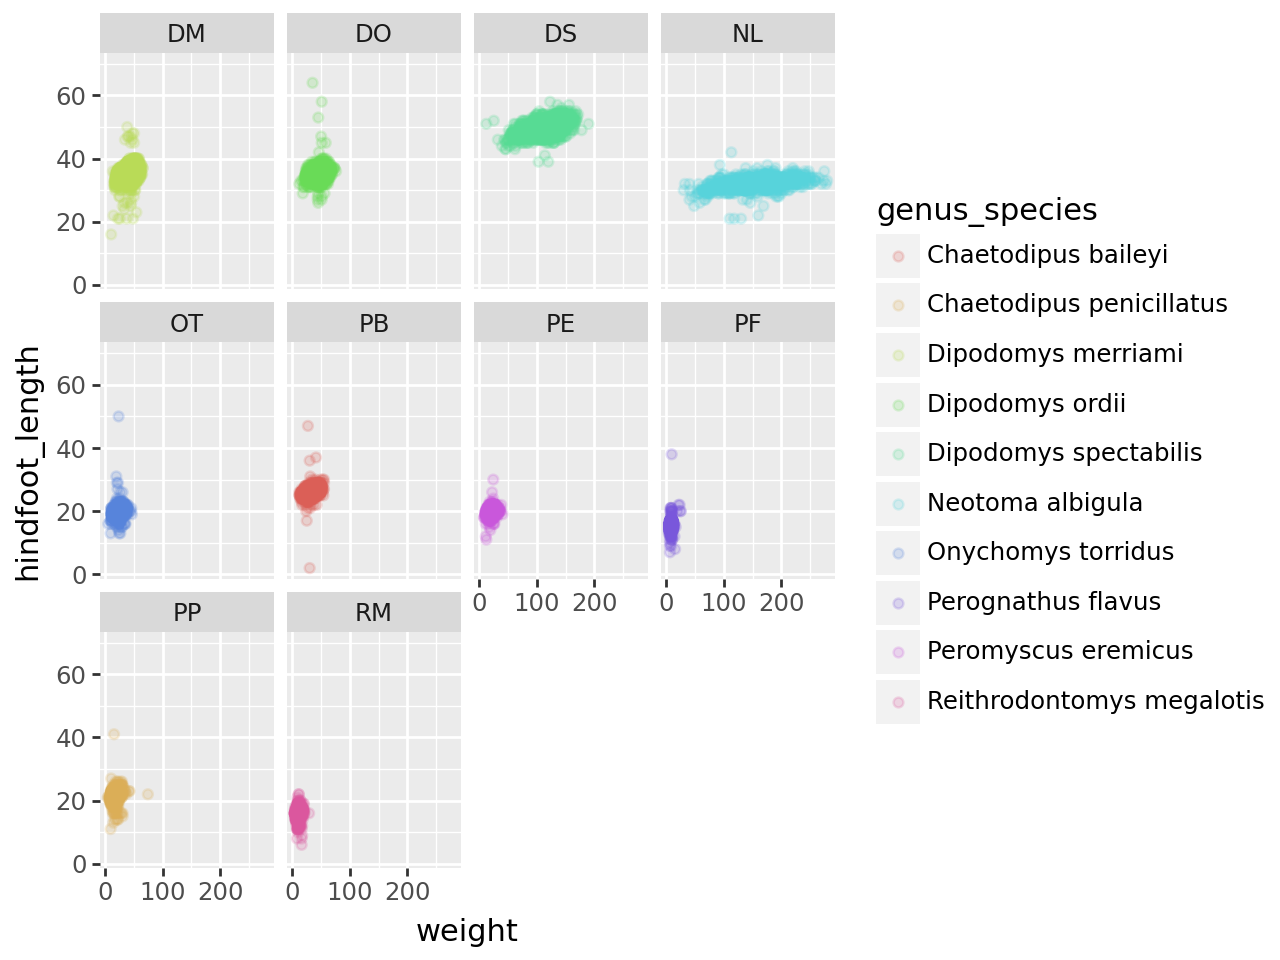

In [57]:
surveys_plot + facet_wrap('~species_id')

## Linear Regression

Let's try a simple regression regression on one of the species' length/weight data.

In [58]:
ds_data = surveys_df[surveys_df.species_id=='DS'][['hindfoot_length', 'weight', 'sex']]

In [59]:
ds_data.head()

,hindfoot_length,weight,sex
10,53.0,NaN,F
16,48.0,NaN,F
19,48.0,NaN,F
29,52.0,NaN,F
41,46.0,NaN,F


In [60]:
ds_data = ds_data[~ds_data.hindfoot_length.isnull() & ~ds_data.weight.isnull() & ~ds_data.sex.isnull()]

In [61]:
ds_data.head()

,hindfoot_length,weight,sex
356,50.0,117.0,F
361,51.0,121.0,F
366,51.0,115.0,M
376,48.0,120.0,F
380,48.0,118.0,F


In [62]:
ds_data[ds_data.sex.isnull()]

,hindfoot_length,weight,sex


In [63]:
import math
import numpy as np
from sklearn.linear_model import LinearRegression

array([[<Axes: title={'center': 'hindfoot_length'}>,
        <Axes: title={'center': 'weight'}>]], dtype=object)

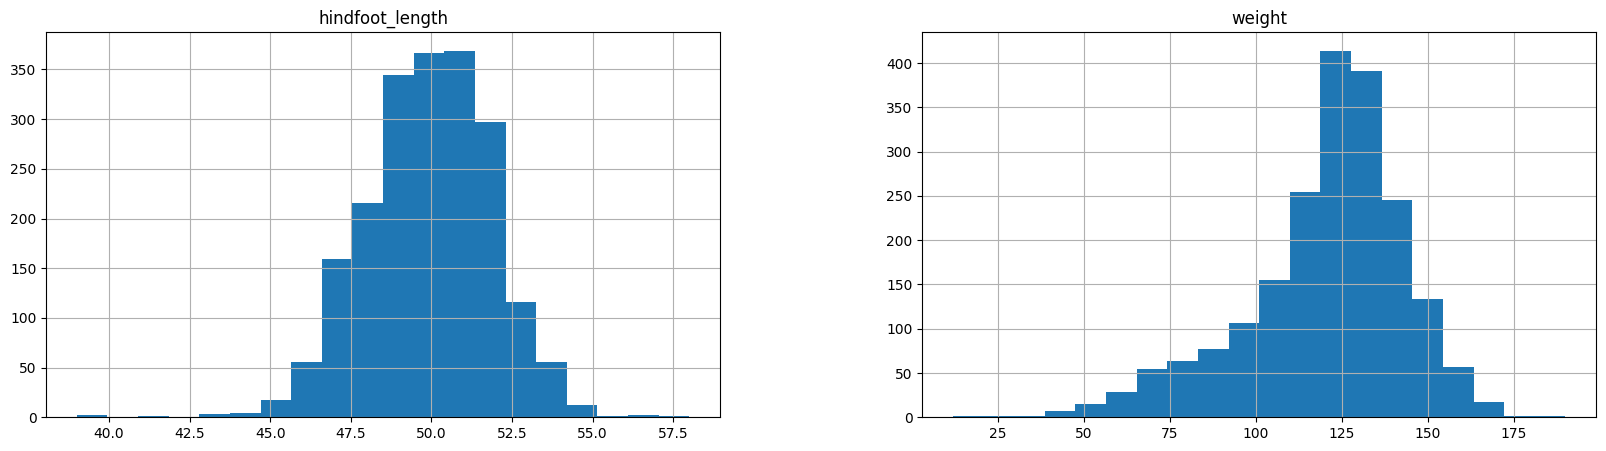

In [64]:
ds_data.hist(bins=20, figsize=(20, 5)) # Creates one histogram per continuous data

In [65]:
100*ds_data['weight']

,weight
356,11700.0
361,12100.0
366,11500.0
376,12000.0
380,11800.0
...,...
29312,15300.0
29432,8700.0
29435,13100.0
29572,9600.0


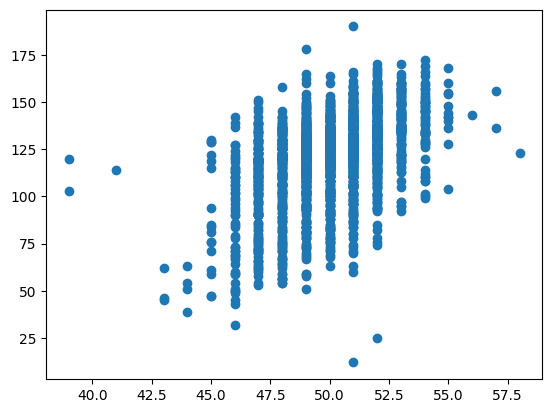

In [66]:
plt.scatter(ds_data.hindfoot_length, ds_data.weight)

In [67]:
#ds_data[['hindfoot_length']]

regr = LinearRegression()
regr.fit(X = ds_data[['hindfoot_length']], y = ds_data[['weight']])

LinearRegression()

In [68]:
regr.coef_

array([[5.33352657]])

In [69]:
regr.intercept_

array([-146.41038521])

In [70]:
# R-squared

regr.score(X = ds_data[['hindfoot_length']], y = ds_data[['weight']])

0.22609420240013156